In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Dataset Collection**

In [2]:
path1 = "/content/drive/MyDrive/Requirement Analysis/archive (3)/nfr.txt"
path2 = "/content/drive/MyDrive/Requirement Analysis/archive (4)/software_requirements_extended.csv"
path3 = "/content/drive/MyDrive/Requirement Analysis/archive (5)/Pure_Annotate_Dataset.csv"

In [13]:
import pandas as pd

df1 = pd.read_csv(
    path1,
    header=None,
    names=['sentence'],
    encoding='latin1'
)

df1['type'] = df1['sentence'].str.extract(r'^([A-Z]+):')

df1['sentence'] = df1['sentence'].str.replace(
    r'^[A-Z]+:',
    '',
    regex=True
)

print(df1.head())
print(df1.shape)

                                            sentence type
0  The system shall refresh the display every 60 ...   PE
1  The application shall match the color of the s...   LF
2   If projected  the data must be readable.  On ...   US
3   The product shall be available during normal ...    A
4   If projected  the data must be understandable...   US
(556, 2)


In [14]:
df2 = pd.read_csv(path2)

df2.columns = ['type', 'sentence']

print(df2.head())
print(df2.shape)

  type                                           sentence
0   PE  The system shall refresh the display every 60 ...
1   LF  The application shall match the color of the s...
2   US   If projected  the data must be readable.  On ...
3    A   The product shall be available during normal ...
4   US   If projected  the data must be understandable...
(977, 2)


In [15]:
df3 = pd.read_csv(path3, encoding='latin1')

print(df3.head())
print(df3.shape)

                                                  id  \
0  CCHIT Certified 2011 Ambulatory EHR Criteria 2...   
1  CCHIT Certified 2011 Ambulatory EHR Criteria 2...   
2  CCHIT Certified 2011 Ambulatory EHR Criteria 2...   
3  CCHIT Certified 2011 Ambulatory EHR Criteria 2...   
4  CCHIT Certified 2011 Ambulatory EHR Criteria 2...   

                                            sentence  security  reliability  \
0  The system shall create a single patient recor...         0            0   
1  The system shall associate (store and link) ke...         0            0   
2  The system shall provide the ability to store ...         0            0   
3  The system shall provide a field which will id...         0            0   
4  The system shall provide the ability to merge ...         0            0   

   NFR_boolean  
0            0  
1            0  
2            0  
3            0  
4            0  
(11440, 5)


# **Dataset Statistics**

In [16]:
print("DATASET 1")
print(df1['type'].value_counts())

print("\nDATASET 2")
print(df2['type'].value_counts())

print("\nDATASET 3")
print(df3['NFR_boolean'].value_counts())

DATASET 1
type
F     210
US     63
O      58
SE     56
PE     54
LF     34
A      21
SC     21
MN     17
L      10
FT     10
PO      2
Name: count, dtype: int64

DATASET 2
type
FR     312
F      209
NFR    110
US      63
O       58
SE      56
PE      54
LF      34
A       21
SC      21
MN      17
L       10
FT      10
PO       2
Name: count, dtype: int64

DATASET 3
NFR_boolean
0    9532
1    1908
Name: count, dtype: int64


In [17]:
df1['label'] = df1['type'].apply(
    lambda x: 0 if x == 'F' else 1
)

In [18]:
df2['label'] = df2['type'].apply(
    lambda x: 0 if x in ['F', 'FR'] else 1
)

In [19]:
df3['label'] = df3['NFR_boolean']

In [20]:
df1 = df1[['sentence', 'label']]
df2 = df2[['sentence', 'label']]
df3 = df3[['sentence', 'label']]

In [21]:
df = pd.concat([df1, df2, df3], ignore_index=True)

print(df.shape)
print(df['label'].value_counts())

(12973, 2)
label
0    10263
1     2710
Name: count, dtype: int64


In [22]:
df.to_csv("dataset_original.csv", index=False)

# **Data Preprocessing and Cleaning**

In [27]:
import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [24]:
stop_words = set(stopwords.words('english'))

In [25]:
def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [28]:
df['cleaned_sentence'] = df['sentence'].apply(preprocess_text)

df[['sentence', 'cleaned_sentence']].head()

,sentence,cleaned_sentence
0,The system shall refresh the display every 60 ...,system shall refresh display every seconds
1,The application shall match the color of the s...,application shall match color schema set forth...
2,If projected the data must be readable. On ...,projected data must readable x projection scre...
3,The product shall be available during normal ...,product shall available normal business hours ...
4,If projected the data must be understandable...,projected data must understandable x projectio...


In [29]:
print("Before Cleaning:", df.shape)

df.drop_duplicates(subset='cleaned_sentence', inplace=True)

df.dropna(inplace=True)

print("After Cleaning:", df.shape)

print(df.isnull().sum())

Before Cleaning: (12973, 3)
After Cleaning: (10618, 3)
sentence            0
label               0
cleaned_sentence    0
dtype: int64


In [30]:
print(df['label'].value_counts())

label
0    8420
1    2198
Name: count, dtype: int64


In [31]:
df.to_csv("dataset_cleaned.csv", index=False)

# **Feature Engineering**

# TF-IDF Feature Extraction

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=1000
)
X = vectorizer.fit_transform(df['cleaned_sentence'])

y = df['label']
print(X.shape)
print(y.shape)

(10618, 1000)
(10618,)


In [33]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['ability' 'able' 'access' 'accessed' 'accessible' 'accordance'
 'according' 'account' 'accounting' 'accounts' 'accreditation' 'accuracy'
 'across' 'act' 'acting' 'action' 'actions' 'active' 'activities'
 'activity']


# **Feature Selection**

# Chi-Square

In [34]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
selector = SelectKBest(
    score_func=chi2,
    k=500
)

X_selected = selector.fit_transform(X, y)
print(X_selected.shape)

(10618, 500)


In [35]:
selected_mask = selector.get_support()

selected_features = feature_names[selected_mask]

print(selected_features[:20])

['ability' 'able' 'access' 'accessed' 'accessible' 'account' 'accounts'
 'accreditation' 'accuracy' 'act' 'actions' 'activity' 'add' 'added'
 'addressable' 'administrator' 'administrators' 'adopted' 'advance'
 'affected']


In [36]:
scores = selector.scores_

feature_scores = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
})

feature_scores = feature_scores.sort_values(
    by='Score',
    ascending=False
)

print(feature_scores.head(10))

           Feature      Score
486           lhcp  92.475140
843          shall  86.449568
256       disclose  84.382048
389            hcp  82.755665
86           audit  78.470304
699        product  77.276400
536        message  62.743036
88   authenticated  59.264142
957          users  58.667664
464         itrust  53.672901


# **Train/Test Split**

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8494, 500)
X_test shape: (2124, 500)
y_train shape: (8494,)
y_test shape: (2124,)


In [38]:
print("Training Distribution")
print(y_train.value_counts())

print("\nTesting Distribution")
print(y_test.value_counts())

Training Distribution
label
0    6736
1    1758
Name: count, dtype: int64

Testing Distribution
label
0    1684
1     440
Name: count, dtype: int64


In [39]:
pd.DataFrame(X_train.toarray()).to_csv("X_train.csv", index=False)
pd.DataFrame(X_test.toarray()).to_csv("X_test.csv", index=False)

pd.DataFrame(y_train).to_csv("y_train.csv", index=False)
pd.DataFrame(y_test).to_csv("y_test.csv", index=False)

# **ML Experiments**

# Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [43]:
y_pred_lr = lr_model.predict(X_test)

In [44]:
accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

Accuracy: 0.8408662900188324
Weighted Precision: 0.8726535805688349
Weighted Recall: 0.8408662900188324
Weighted F1-score: 0.8500278871240503


In [45]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      0.85      0.89      1684
           1       0.58      0.82      0.68       440

    accuracy                           0.84      2124
   macro avg       0.77      0.84      0.79      2124
weighted avg       0.87      0.84      0.85      2124



# Naive Bayes

In [46]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [47]:
accuracy = accuracy_score(y_test, y_pred_nb)

precision = precision_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

Accuracy: 0.8488700564971752
Weighted Precision: 0.8386344210273411
Weighted Recall: 0.8488700564971752
Weighted F1-score: 0.830003303334454


In [48]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1684
           1       0.76      0.40      0.52       440

    accuracy                           0.85      2124
   macro avg       0.81      0.68      0.72      2124
weighted avg       0.84      0.85      0.83      2124



# Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

In [50]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [51]:
accuracy = accuracy_score(y_test, y_pred_rf)

precision = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

Accuracy: 0.8695856873822976
Weighted Precision: 0.8620177552111743
Weighted Recall: 0.8695856873822976
Weighted F1-score: 0.8620956469762823


In [52]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1684
           1       0.75      0.56      0.64       440

    accuracy                           0.87      2124
   macro avg       0.82      0.75      0.78      2124
weighted avg       0.86      0.87      0.86      2124



# K-NN

In [53]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(
    n_neighbors=5
)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test, y_pred_knn)

precision = precision_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

Accuracy: 0.841337099811676
Weighted Precision: 0.8286059964159945
Weighted Recall: 0.841337099811676
Weighted F1-score: 0.8204489156984872


In [55]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.85      0.96      0.91      1684
           1       0.73      0.37      0.49       440

    accuracy                           0.84      2124
   macro avg       0.79      0.67      0.70      2124
weighted avg       0.83      0.84      0.82      2124



# Linear SVC

In [56]:
from sklearn.svm import LinearSVC
svc_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)

In [57]:
accuracy = accuracy_score(y_test, y_pred_svc)

precision = precision_score(
    y_test,
    y_pred_svc,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_svc,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_svc,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

Accuracy: 0.8361581920903954
Weighted Precision: 0.8713422162929074
Weighted Recall: 0.8361581920903954
Weighted F1-score: 0.8460880625575364


In [58]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1684
           1       0.57      0.83      0.68       440

    accuracy                           0.84      2124
   macro avg       0.76      0.83      0.78      2124
weighted avg       0.87      0.84      0.85      2124



# XG Boost

In [59]:
from xgboost import XGBClassifier

In [60]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [61]:
accuracy = accuracy_score(y_test, y_pred_xgb)

precision = precision_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

Accuracy: 0.8587570621468926
Weighted Precision: 0.8506245271781995
Weighted Recall: 0.8587570621468926
Weighted F1-score: 0.8433045261915985


In [62]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1684
           1       0.78      0.45      0.57       440

    accuracy                           0.86      2124
   macro avg       0.82      0.71      0.74      2124
weighted avg       0.85      0.86      0.84      2124



# Normalized Confusion Matrix

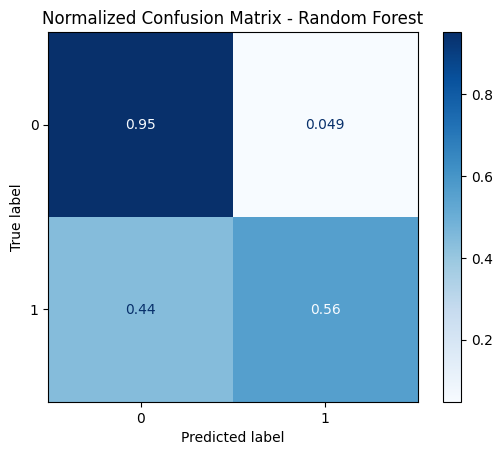

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    normalize='true',
    cmap='Blues'
)

plt.title("Normalized Confusion Matrix - Random Forest")

plt.show()

# **Baseline Experiment(Without Data Removal)**

In [64]:
vectorizer_base = TfidfVectorizer(
    max_features=1000
)

X_base = vectorizer_base.fit_transform(df['sentence'])

y_base = df['label']

In [65]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
)

In [66]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_base.fit(X_train_base, y_train_base)

y_pred_base = rf_base.predict(X_test_base)

In [67]:
print("Baseline Accuracy:",
      accuracy_score(y_test_base, y_pred_base))

print("Baseline Weighted F1:",
      f1_score(
          y_test_base,
          y_pred_base,
          average='weighted'
      ))

Baseline Accuracy: 0.8691148775894538
Baseline Weighted F1: 0.8573525987926328


**Experiment with Data Removal**

In [68]:
vectorizer_clean = TfidfVectorizer(
    max_features=1000
)

X_clean = vectorizer_clean.fit_transform(
    df['cleaned_sentence']
)

y_clean = df['label']

In [69]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

In [70]:
rf_clean = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_clean.fit(X_train_clean, y_train_clean)

y_pred_clean = rf_clean.predict(X_test_clean)

In [71]:
print("Cleaned Accuracy:",
      accuracy_score(y_test_clean, y_pred_clean))

print("Cleaned Weighted F1:",
      f1_score(
          y_test_clean,
          y_pred_clean,
          average='weighted'
      ))

Cleaned Accuracy: 0.8808851224105462
Cleaned Weighted F1: 0.8746166636694156


# **Comparative Experimental Results**

In [72]:
comparison_df = pd.DataFrame({
    'Experiment': [
        'Baseline',
        'Cleaning Only',
        'Cleaning + Feature Selection'
    ],
    'Accuracy': [
        accuracy_score(y_test_base, y_pred_base),
        accuracy_score(y_test_clean, y_pred_clean),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Weighted F1': [
        f1_score(y_test_base, y_pred_base, average='weighted'),
        f1_score(y_test_clean, y_pred_clean, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

print(comparison_df)

                     Experiment  Accuracy  Weighted F1
0                      Baseline  0.869115     0.857353
1                 Cleaning Only  0.880885     0.874617
2  Cleaning + Feature Selection  0.869586     0.862096
